<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
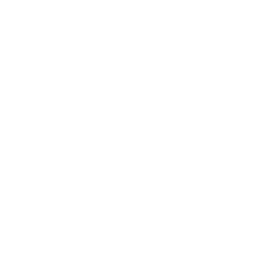
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">建物エネルギー効率クラスタリング</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; エネルギー / サステナビリティ分析 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

この実例では、商業ビルのポートフォリオを5つのエネルギー効率指標――エネルギー使用原単位(EUI)、HVAC効率比、外皮熱抵抗、照明電力密度、再生可能エネルギー比率――によってクラスタリングし、公益事業のリベート対象選定のために明確な性能ティアを可視化する。分析には **PROC FASTCLUS** を `REPLACE=FULL`（シード全置換）で用い、k=3、4、5、6の各解を全体R二乗値、疑似F統計量、最小クラスタサイズの観点で比較する。その上でk=4解を詳細にプロファイリングし、各クラスタを実行可能な効率ティアへとマッピングする。この環境はライセンスなしで動作するため、デモンストレーションは100棟のサンプルに限定されるが、同じプログラムはそのままフルポートフォリオにも拡張できる。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | 建物ごとの年間エネルギー効率指標（合成データ） | 100 |


---

In [1]:
/* --------------------------------------------------------
   合成の建物エネルギー指標を生成
   商業ビルの効率指標
   -------------------------------------------------------- */
データ work.building_metrics;
    呼出 streaminit(42);
    長さ building_type $16 climate_region $14;
    繰返 building_id = 1 から 5000;
        /* 建物用途（配列ではなく if/else で日本語ラベルを割当。
           _temporary_ 配列は多バイト値を切り詰めるため使用しない） */
        type_idx = int(rand('uniform') * 5) + 1;
        もし type_idx = 1 なら building_type = 'オフィス';
        他 もし type_idx = 2 なら building_type = '小売店舗';
        他 もし type_idx = 3 なら building_type = '倉庫';
        他 もし type_idx = 4 なら building_type = '病院';
        他 building_type = '学校';
        /* 気候区分（同じ理由で if/else を使用） */
        reg_idx = int(rand('uniform') * 4) + 1;
        もし reg_idx = 1 なら climate_region = '北東部';
        他 もし reg_idx = 2 なら climate_region = '南東部';
        他 もし reg_idx = 3 なら climate_region = '中西部';
        他 climate_region = '西部';

        /* エネルギー使用原単位 (kBtu/sqft/yr) */
        eui = round(rand('normal', 85, 35), 0.1);
        もし eui < 15 なら eui = 15;
        もし eui > 250 なら eui = 250;

        /* HVAC効率比（COP相当） */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        もし hvac_efficiency < 1.0 なら hvac_efficiency = 1.0;
        もし hvac_efficiency > 6.0 なら hvac_efficiency = 6.0;

        /* 外皮熱抵抗（R値） */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        もし envelope_r_value < 5 なら envelope_r_value = 5;
        もし envelope_r_value > 40 なら envelope_r_value = 40;

        /* 照明電力密度 (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        もし lighting_wpf < 0.3 なら lighting_wpf = 0.3;
        もし lighting_wpf > 2.5 なら lighting_wpf = 2.5;

        /* 再生可能エネルギー比率 */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        もし renewable_pct > 80 なら renewable_pct = 80;

        /* 築年数 */
        building_age = int(rand('uniform') * 80) + 1;

        /* 延床面積（千sqft） */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        もし floor_area_ksf > 500 なら floor_area_ksf = 500;

        出力;
    終了;
    削除 type_idx reg_idx;
実行;



NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.84 seconds
  cpu   1.84 seconds


---

In [2]:
/* --------------------------------------------------------
   建物用途別のベースラインエネルギー指標分布
   -------------------------------------------------------- */
処理 平均 データ=work.building_metrics n mean std;
    分類 building_type;
    変数 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    見出 building_type='建物用途' eui='EUI(kBtu/sqft/yr)'
          hvac_efficiency='HVAC効率(COP)' envelope_r_value='外皮熱抵抗(R値)'
          lighting_wpf='照明電力密度(W/sqft)' renewable_pct='再生可能エネルギー比率(%)';
    表題 '建物用途別 エネルギー指標';
実行;


                                                     建物用途別 エネルギー指標                                                      

                                                  The MEANS Procedure

                                       Analysis Variable : eui EUI(kBtu/sqft/yr)

        建物用途                  N Obs           Mean        Std Dev
        ---------------------------------------------------------
        オフィス                     20     73.0550000     40.3950163
        倉庫                       20     90.8900000     33.5993249
        学校                       19     89.7000000     39.0498542
        小売店舗                     16     79.7312500     42.6818106
        病院                       25     87.9040000     35.2632892
        ---------------------------------------------------------

                                  Analysis Variable : hvac_efficiency HVAC効率(COP)

        建物用途                  N Obs           Mean        Std Dev
        ---------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                                     建物用途別 エネルギー指標                                                      




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


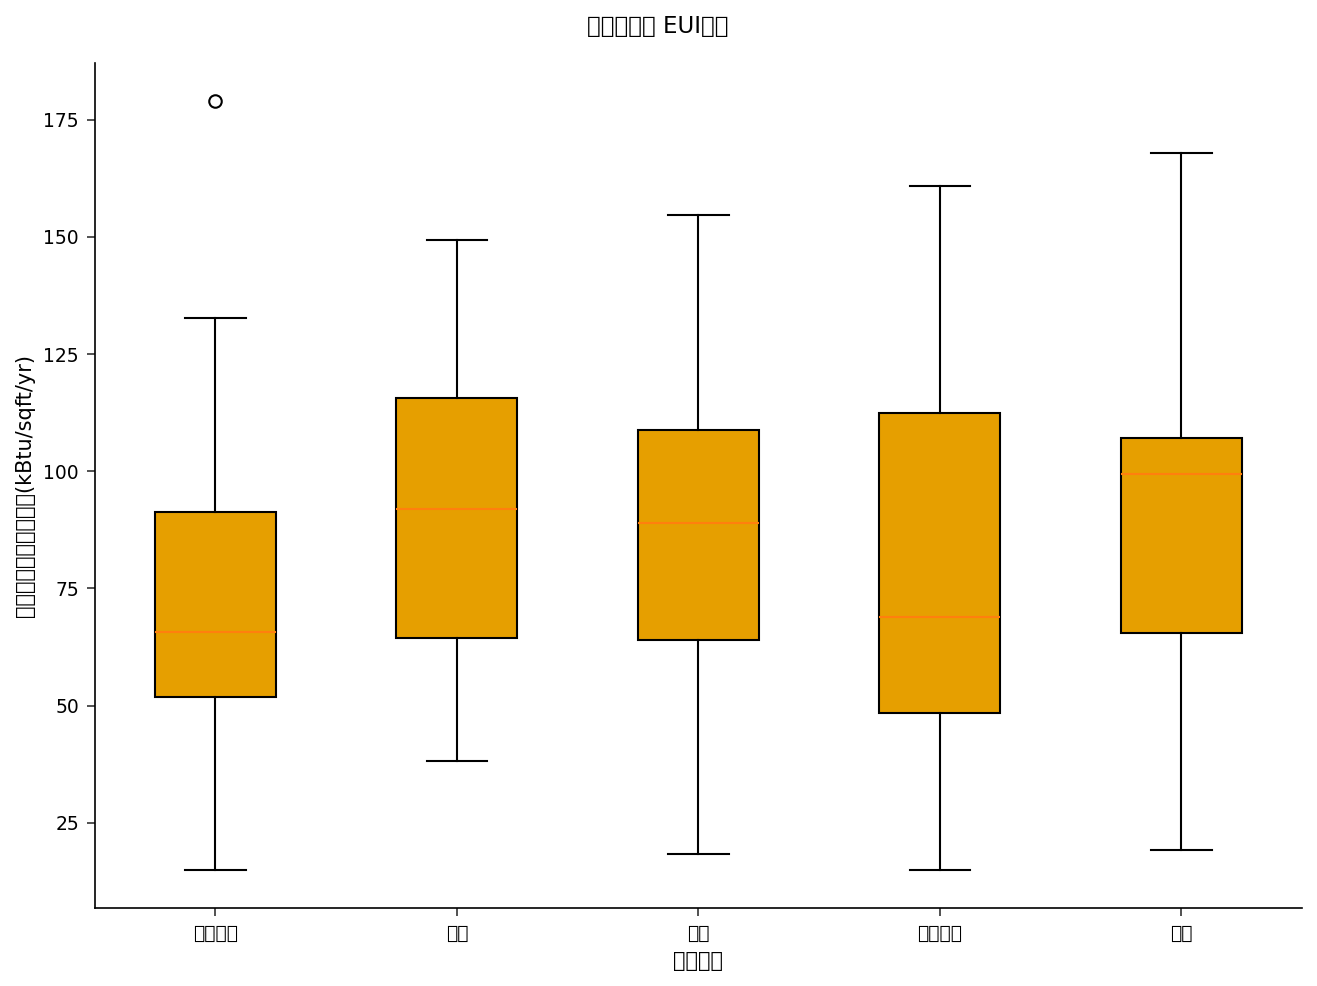

In [3]:
/* --------------------------------------------------------
   建物用途別のEUI分布
   -------------------------------------------------------- */
処理 SGPLOT データ=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS 見出='建物用途';
    YAXIS 見出='エネルギー使用原単位(kBtu/sqft/yr)';
    表題 '建物用途別 EUI分布';
実行;


---

In [4]:
/* --------------------------------------------------------
   効率指標を標準化
   -------------------------------------------------------- */
処理 標準 データ=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    変数 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
実行;



NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   k平均法クラスタリング: k=3、REPLACE=FULL
   -------------------------------------------------------- */
処理 FASTCLUS データ=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    変数 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    見出 eui='EUI(kBtu/sqft/yr)' hvac_efficiency='HVAC効率(COP)'
          envelope_r_value='外皮熱抵抗(R値)' lighting_wpf='照明電力密度(W/sqft)'
          renewable_pct='再生可能エネルギー比率(%)';
    表題 '建物効率クラスタリング: k=3 REPLACE=FULL';
実行;


                                                     建物用途別 エネルギー指標                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   k平均法クラスタリング: k=4、REPLACE=FULL
   -------------------------------------------------------- */
処理 FASTCLUS データ=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    変数 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    見出 eui='EUI(kBtu/sqft/yr)' hvac_efficiency='HVAC効率(COP)'
          envelope_r_value='外皮熱抵抗(R値)' lighting_wpf='照明電力密度(W/sqft)'
          renewable_pct='再生可能エネルギー比率(%)';
    表題 '建物効率クラスタリング: k=4 REPLACE=FULL';
実行;


                                                     建物用途別 エネルギー指標                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   k平均法クラスタリング: k=5、REPLACE=FULL
   -------------------------------------------------------- */
処理 FASTCLUS データ=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    変数 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    見出 eui='EUI(kBtu/sqft/yr)' hvac_efficiency='HVAC効率(COP)'
          envelope_r_value='外皮熱抵抗(R値)' lighting_wpf='照明電力密度(W/sqft)'
          renewable_pct='再生可能エネルギー比率(%)';
    表題 '建物効率クラスタリング: k=5 REPLACE=FULL';
実行;


                                                     建物用途別 エネルギー指標                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   k平均法クラスタリング: k=6、REPLACE=FULL
   -------------------------------------------------------- */
処理 FASTCLUS データ=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    変数 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    見出 eui='EUI(kBtu/sqft/yr)' hvac_efficiency='HVAC効率(COP)'
          envelope_r_value='外皮熱抵抗(R値)' lighting_wpf='照明電力密度(W/sqft)'
          renewable_pct='再生可能エネルギー比率(%)';
    表題 '建物効率クラスタリング: k=6 REPLACE=FULL';
実行;


                                                     建物用途別 エネルギー指標                                                      


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   k=3-6でのクラスタ品質を比較
   クラスタ内R二乗値と最小クラスタサイズを計算
   -------------------------------------------------------- */
%macro cluster_quality(k);
処理 度数 データ=work.bldg_clust&k NOPRINT;
    TABLES cluster / out=work.freq_k&k (改名=(count=n_buildings));
実行;

処理 SQL NOPRINT;
    選択 MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);


                                                     建物用途別 エネルギー指標                                                      

                                                     建物用途別 エネルギー指標                                                      

                                                     建物用途別 エネルギー指標                                                      

                                                     建物用途別 エネルギー指標                                                      




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                                   建物効率ティアプロファイル(k=4)                                                   

                                                  The MEANS Procedure

                                       Analysis Variable : eui EUI(kBtu/sqft/yr)

                                                    N
                                  クラスタ            Obs             Mean         Std Dev
                                  ----------------------------------------------------
                                  1                23       63.7782609      31.5423086
                                  2                17      122.5941176      36.0679995
                                  3                26       94.0076923      30.8825378
                                  4                34       72.3911765      31.7411154
                                  ----------------------------------------------------

                                   Analysis Variable : hvac_e


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


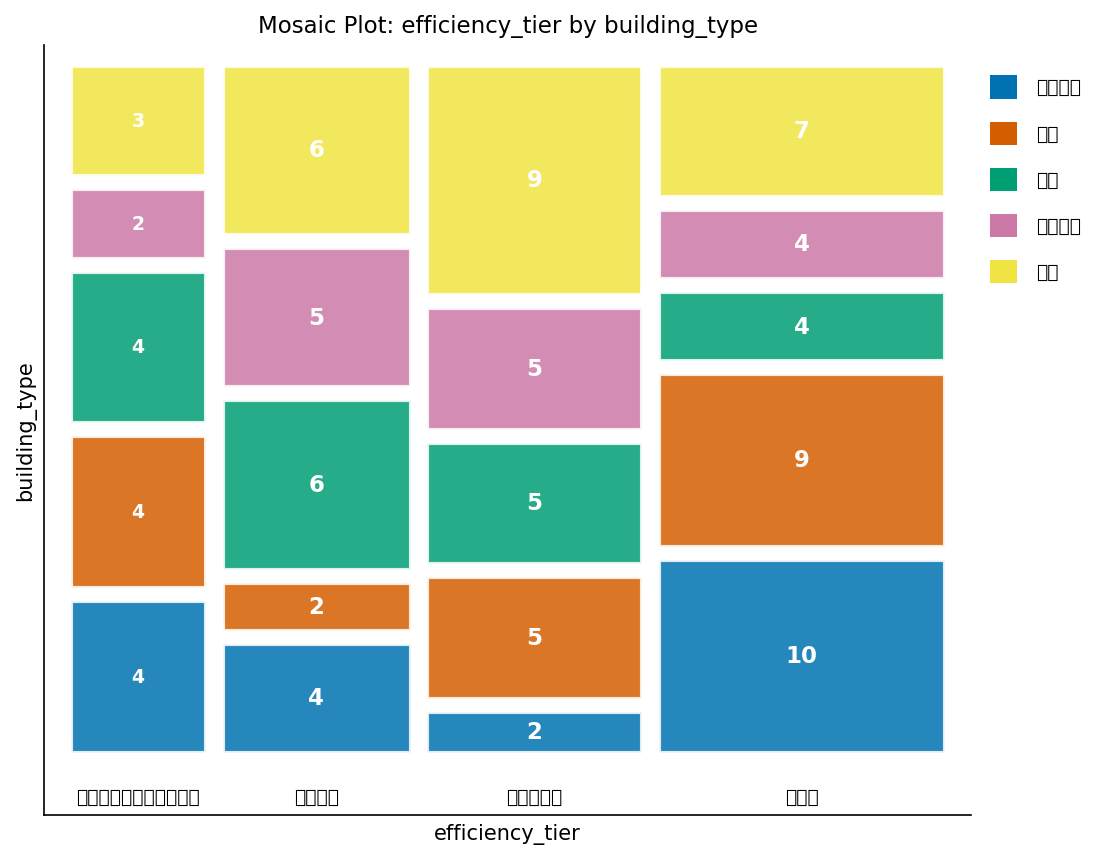

In [10]:
/* --------------------------------------------------------
   選定したk=4解をプロファイリング
   -------------------------------------------------------- */
データ work.bldg_profiled;
    結合 work.building_metrics
          work.bldg_clust4 (保持=building_id cluster distance);
    基準 building_id;
実行;

処理 平均 データ=work.bldg_profiled mean std;
    分類 cluster;
    変数 eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    見出 cluster='クラスタ' eui='EUI(kBtu/sqft/yr)' hvac_efficiency='HVAC効率(COP)'
          envelope_r_value='外皮熱抵抗(R値)' lighting_wpf='照明電力密度(W/sqft)'
          renewable_pct='再生可能エネルギー比率(%)' building_age='築年数';
    表題 '建物効率ティアプロファイル(k=4)';
実行;

/* 観測されたk=4のセントロイドから効率ティアをラベル付け:
   クラスタ4 = 最良HVAC(3.89)、低EUI  -> 高効率
   クラスタ2 = 最高再生可能エネルギー比率(28%)だが最高EUI -> 再生可能エネルギー多用
   クラスタ3 = 最高照明負荷、弱いHVAC、中位EUI -> 照明負荷大
   クラスタ1 = 低EUIだが最弱HVAC + 最薄外皮 -> 改修優先 */
データ work.bldg_tiered;
    設定 work.bldg_profiled;
    長さ efficiency_tier $40;
    もし cluster = 4 なら efficiency_tier = '高効率';
    他 もし cluster = 2 なら efficiency_tier = '再生可能エネルギー多用';
    他 もし cluster = 3 なら efficiency_tier = '照明負荷大';
    他 もし cluster = 1 なら efficiency_tier = '改修優先';
実行;

処理 度数 データ=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    見出 efficiency_tier='効率ティア' building_type='建物用途';
    表題 '建物用途別 効率ティア';
実行;


---

### 解釈

`REPLACE=FULL` により、すべてのk値がクリーンに収束した。4つの解を通じて、全体R二乗値はkとともに単調に上昇した――0.305 (k=3)、0.410 (k=4)、0.459 (k=5)、0.515 (k=6)――一方で疑似F統計量は **k=4 (22.23)** でピークとなり、その後低下した（k=5で20.13、k=6で19.93）。k=4での最小クラスタサイズ17棟（k=5では13棟、k=6では10棟）と合わせると、**k=4解** が分離度とティアの安定性の最良のバランスを提供するため、以下ではこの解を詳細にプロファイリングする。

k=4の4つのクラスタは、明確に異なる効率プロファイルにマッピングされる（上のPROC MEANSプロファイルの平均値より）:

- **高効率（クラスタ4、n=34）:** 最も設備の整ったグループ――最高のHVAC効率（COP 3.89）を低～中程度のEUI 72.4 kBtu/sqft/yrで達成し、十分な外皮性能（R 18.8）と控えめな再生可能エネルギー比率（11.0%）を持つ。
- **再生可能エネルギー多用（クラスタ2、n=17）:** 絶対的な消費量が最も高い（EUI 122.6）が、再生可能エネルギー比率も群を抜いて最高（28.2%）であり、HVACは中程度（COP 3.42）。高い出力とオンサイト発電を両立している。
- **照明負荷大（クラスタ3、n=26）:** 最も厚い外皮（R 19.6）にもかかわらず、最高の照明電力密度（1.35 W/sqft）と2番目に弱いHVAC（COP 2.42）に起因する中位のEUI（94.0）。
- **改修優先（クラスタ1、n=23）:** 見かけ上は低いEUI（63.8）だが、最も弱いHVAC（COP 2.28）と最も薄い外皮（R 12.5）を持つ――小規模または利用頻度が低いが設備の貧弱な建物であり、外皮・HVAC改修の最も明確な候補である。

ティア別・建物用途別のクロス集計では、オフィス（10）と倉庫（9）が高効率ティアで優勢であり、病院は照明負荷大ティアに集中している（26件中9件）。改修優先ティアは各用途に分散しているが、病院と学校が最多（それぞれ23件中6件）である。プログラム設計上、改修優先23棟と照明負荷大26棟はそれぞれHVACおよび照明インセンティブの自然な対象であり、一方で再生可能エネルギー多用の17棟――既にオンサイト発電を行っている――は、さらなる発電リベートよりも需要削減策の方が適している。

---

In [11]:
/* --------------------------------------------------------
   建物効率ティアとセントロイドプロファイルをエクスポート
   -------------------------------------------------------- */
処理 EXPORT データ=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
実行;



NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供： <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>